In [3]:
# for data science and cleaning data
import pandas as pd

# for spatial analysis
import osmnx as ox
import folium

# for graph analysis
import networkx as nx
from networkx.algorithms import bipartite
import random # for random sampling; not giving you all of my leads

# for graph visualization
import numpy as np
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix
from IPython.display import display # to render it from the function

data = r"C:\Users\itsgo\PythonCode\verdant_intelligence\exports\grooveseeker_scene\spatial_local_leads.csv"

In [4]:
df = pd.read_csv(data)
df.head()

,business_name,type,nearest_city,address,phone_number,pindrop_address
0,Fitness 1440,sports_centre,Forest Grove,2329 Pacific Avenue,+1-503-746-7819,"2004 Main St, Forest Grove, OR 97116"
1,Pizza Hut,restaurant,Forest Grove,2323 Pacific Avenue,+1 503-357-3368,"2004 Main St, Forest Grove, OR 97116"
2,Cornerstone Pub & Grill,restaurant,Forest Grove,2307 Pacific Avenue,+1-503-357-4742,"2004 Main St, Forest Grove, OR 97116"
3,La Sierra,restaurant,Forest Grove,2331 Pacific Avenue,+1-503-992-8980,"2004 Main St, Forest Grove, OR 97116"
4,Tuality Physical Therapy,physical_therapist,Forest Grove,2333 Pacific Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"


# Methodology

Today is a continuation of yesterday's work. I am using the OSINT leads I captured and doing some preprocessing to put it into a more usable form. Basically, I want to denoise this and end up with multiple datasets that are helpful depending on the type of lead I am working on reaching out to.

Today's work:
- Explore: I will use Bipartite Projection to make short work of grouping and then explore the data
- Split: I will then split the data by the identified groups and create multiple datasets

That's it. These are the outcomes I want to reach. Done is done.

# Explore

I used my own articles to remember how to do this. :)
- https://100daysofnetworks.substack.com/p/day-83-of-100daysofnetworks
- https://github.com/itsgorain/100daysofnetworks/blob/main/day_83_verdant_punk_rock.ipynb

That is another helpful article and code to learn from.

In [5]:
def draw_graph(G, show_names=True, node_size=5, font_size=10, edge_width=1, scores=True):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores=scores, edge_width=edge_width)
    
    return SVG(image)

In [6]:
def inspect_component(G, component, show_graph=True):

    nodes = sorted(component)

    if show_graph:
        display(draw_graph(G.subgraph(nodes), edge_width=0.2))

    sample = sorted(random.sample(nodes, min(10, len(nodes))))

    for n in sample:
        print(n)

In [7]:
B = nx.from_pandas_edgelist(df, source='business_name', target='type')

G_businesses = bipartite.projected_graph(B, df['business_name'])
G_types = bipartite.projected_graph(B, df['type'])

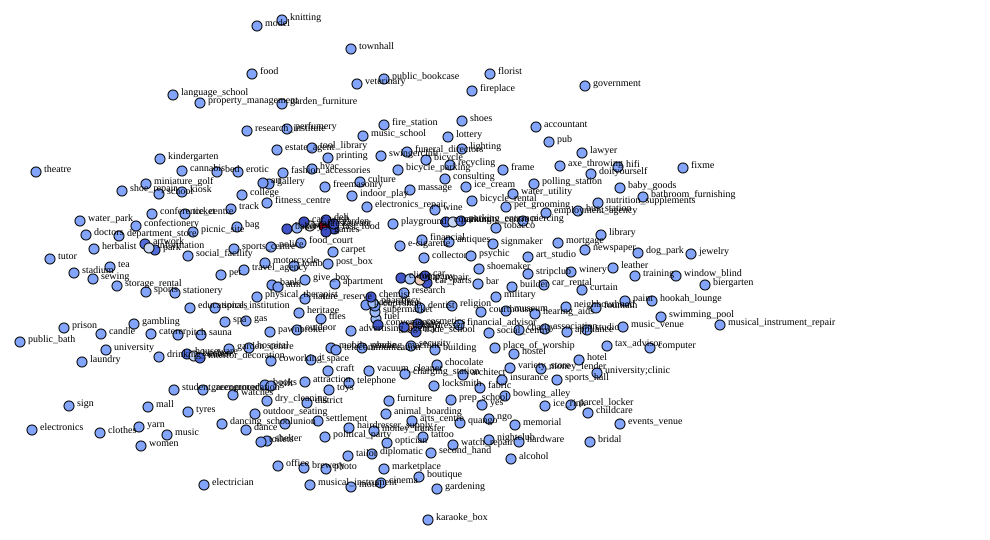

In [8]:
draw_graph(G_types) # interesting; there is some grouping! look for the red or lighter colored nodes to see hints.

In [9]:
# draw_graph(G_businesses) # too slow; too many; visualize the connected components instead

In [10]:
components = list(nx.connected_components(G_businesses))
components = sorted(nx.connected_components(G_businesses), key=len, reverse=True)

len(components)

256

In [11]:
inspect_component(G_businesses, components[0], show_graph=False)

Coffee Works by p:ear
Higgins
Karver Sandwich Bar
Nong's Khao Man Gai
Pho Gia
Rosales Taqueria
Rukdiew Cafe
Teriyaki Moto
Thai Peacock
The Daily Feast


In [12]:
inspect_component(G_businesses, components[1], show_graph=False)

Downstream
EDP Renewables
Fix Auto
Fuel Monkey Performance
Kuni Auto Center
Mad Dog Garage
Midas
NAPA Auto Parts
Steve's Automotive
Tripwire


In [13]:
inspect_component(G_businesses, components[2], show_graph=False)

C-Max
Chong's Hair Design
DITA Barbers Beaverton
Europa
Gilded Opal
Haute Coiffure
Iolite
Jini Hair Salon
Kanani Pearl
The Natural Nails


In [14]:
inspect_component(G_businesses, components[3], show_graph=False) # really interesting!

Cat in Repose
Common Threads
Floribunda
Hidden Creek Park East
Laurelhurst Park
Portlandia
Rogers Park
Tanner Springs Park
The Green Man of Portland
Ventana al Pacifico


In [15]:
inspect_component(G_businesses, components[4], show_graph=False) # venues and bars!

Arcade 2084
Arden
Bar Dolly
Bootleggers
Mbar
Suavecito Bar & Grill
Sugar Hill
Swine
The Side Street Tavern
The Westgate Bourbon Bar & Taphouse


In [16]:
inspect_component(G_businesses, components[5], show_graph=False)

Collier
Icebreaker
LaHaie's
Louis Vuitton
Mercantile
Nau
Plato's Closet
The Children's Shop
True Society by The White Dress
Zara


In [17]:
inspect_component(G_businesses, components[6], show_graph=False)

Alder Street Garage
B-Lot
Hillsboro Community Senior Center
Jackson Bottom Wetlands North Parking
Lot-O
Lovejoy Medical Parking
P7
PMC
The John & Marlis Carson Center
West End Theater


In [18]:
inspect_component(G_businesses, components[7], show_graph=False)

76
El Ranchito
ExtraMile
Hillsboro Pharmacy and Fountain
Junior's
Ma & Pa Market
Standard
Su Casa Super Mercado
Supermercados Mexico
TK Grocery & Deli


In [19]:
inspect_component(G_businesses, components[8], show_graph=False)

Eighth Church of Christ Scientist
First United Methodist Church of Beaverton
Forest Grove United Church of Christ
Havurah Shalom
Hillsboro Friends Church
Saint Anthony Catholic Church
Saint Bartholomews Episcopal Church
Saint Cecilia Catholic Church
Sixth Church of Christ, Scientist
United Methodist Church


In [20]:
inspect_component(G_businesses, components[9], show_graph=False)

Family Promise
Hillsboro Women, Infants and Children (WIC)
Holladay Park Plaza
Merrill Gardens
MorningStar at Laurelhurst
Operation Nightwatch Downtown Hospitality Center
River District Navigation Center
Supportive Housing
The Salvation Army Tualatin Valley Citadel
Women, Infants and Children (WIC) Beaverton


# Company Grouping Looks Good

The Connected component is showing good grouping fro the companies. Now I am curious about the company types. Let's inspect them and see if we can clean the data a bit by identifying what is not a good lead for me right now.

In [21]:
components = list(nx.connected_components(G_types))
components = sorted(nx.connected_components(G_types), key=len, reverse=True)

len(components)

256

In [22]:
inspect_component(G_types, components[0], show_graph=False)

bakery
cafe
car_wash
deli
fast_food
games
garden
pastry
restaurant


In [23]:
inspect_component(G_types, components[1], show_graph=False)

chemist
convenience
fuel
pharmacy
supermarket


In [24]:
inspect_component(G_types, components[2], show_graph=False)

car
car_parts
car_repair
clinic
company


In [25]:
inspect_component(G_types, components[3], show_graph=False)

beauty
cosmetics
hairdresser
trade_school


In [26]:
inspect_component(G_types, components[4], show_graph=False)

community_centre
parking
parking_entrance


In [27]:
inspect_component(G_types, components[5], show_graph=False)

artwork
information
park


In [28]:
inspect_component(G_types, components[6], show_graph=False)

houseware
interior_decoration
kitchen


In [29]:
inspect_component(G_types, components[7], show_graph=False)

art
gallery


In [30]:
inspect_component(G_types, components[8], show_graph=False)

atm
bank


In [31]:
inspect_component(G_types, components[9], show_graph=False)

copyshop
post_office


In [32]:
[print(n) for n in sorted([n for component in components for n in component])]

accountant
advertising_agency
alcohol
animal_boarding
antiques
apartment
appliance
architect
art
art_studio
arts_centre
artwork
association
atm
attraction
axe_throwing
baby_goods
bag
bakery
bank
bar
bathroom_furnishing
beauty
bed
bicycle
bicycle_parking
bicycle_rental
biergarten
books
boutique
bowling_alley
brewery
bridal
builder
building
bus_station
cafe
candle
cannabis
car
car_parts
car_rental
car_repair
car_wash
carpet
caterer
charging_station
charity
chemist
childcare
chocolate
cinema
clinic
clothes
collector
college
community_centre
company
computer
confectionery
conference_centre
consulting
convenience
copyshop
cosmetics
courthouse
coworking_space
craft
culture
curtain
dance
dancing_school
deli
dentist
department_store
diplomatic
district
doctors
dog_park
doityourself
drinking_water
dry_cleaning
e-cigarette
educational_institution
electrician
electronics
electronics_repair
employment_agency
erotic
estate_agent
events_venue
fabric
fashion_accessories
fast_food
financial
financial_

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

# AI Assist Starts Here

Next, I asked ChatGPT to help me create groups that I'll use to create leadgen datasets.

My chat prompt: "these are the types. i need you to group them so that we can use the groups to create datasets."

In [33]:
type_groups = {

    'food_drink': [
        'alcohol', 'bakery', 'bar', 'biergarten', 'brewery', 'cafe',
        'caterer', 'chocolate', 'confectionery', 'convenience', 'deli',
        'fast_food', 'food', 'food_court', 'greengrocer', 'hookah_lounge',
        'ice_cream', 'outdoor_seating', 'pastry', 'pub', 'restaurant',
        'spices', 'supermarket', 'tea', 'tobacco', 'wine', 'winery'
    ],

    'arts_culture_entertainment': [
        'art', 'art_studio', 'arts_centre', 'artwork', 'attraction',
        'cinema', 'collector', 'craft', 'culture', 'dance', 'events_venue',
        'frame', 'gallery', 'games', 'heritage', 'karaoke_box', 'museum',
        'music', 'music_venue', 'nightclub', 'photo', 'studio', 'theatre',
        'ticket'
    ],

    'sports_recreation': [
        'axe_throwing', 'bicycle', 'bicycle_rental', 'bowling_alley',
        'dog_park', 'fitness_centre', 'ice_rink', 'indoor_play',
        'miniature_golf', 'park', 'picnic_site', 'pitch', 'playground',
        'public_bath', 'sauna', 'sports', 'sports_centre', 'sports_hall',
        'stadium', 'swimming_pool', 'track', 'water_park'
    ],

    'health_wellness_beauty': [
        'animal_boarding', 'beauty', 'chemist', 'clinic', 'cosmetics',
        'dentist', 'doctors', 'hairdresser', 'hairdresser_supply',
        'hearing_aids', 'herbalist', 'hospital', 'massage',
        'nutrition_supplements', 'optician', 'perfumery', 'pet_grooming',
        'pharmacy', 'physical_therapist', 'piercing', 'spa', 'tattoo',
        'university;clinic', 'veterinary'
    ],

    'education_learning': [
        'childcare', 'college', 'dancing_school',
        'educational_institution', 'kindergarten', 'language_school',
        'library', 'music_school', 'prep_school', 'public_bookcase',
        'research', 'research_institute', 'school', 'trade_school',
        'training', 'tutor', 'university'
    ],

    'retail_shopping': [
        'antiques', 'appliance', 'baby_goods', 'bag', 'bed', 'books',
        'boutique', 'bridal', 'candle', 'clothes', 'department_store',
        'electronics', 'fabric', 'fashion_accessories', 'florist',
        'furniture', 'garden_centre', 'garden_furniture', 'gift',
        'hardware', 'hifi', 'houseware', 'jewelry', 'kiosk', 'kitchen',
        'knitting', 'leather', 'lighting', 'mall', 'marketplace', 'model',
        'musical_instrument', 'outdoor', 'paint', 'pet', 'second_hand',
        'shoes', 'stationery', 'toys', 'vacuum_cleaner', 'variety_store',
        'vending_machine', 'watches', 'yarn'
    ],

    'professional_business_services': [
        'accountant', 'advertising_agency', 'architect', 'company',
        'consulting', 'copyshop', 'coworking_space', 'dry_cleaning',
        'employment_agency', 'financial_advisor', 'funeral_directors',
        'insurance', 'it', 'laundry', 'lawyer', 'office', 'printing',
        'property_management', 'security', 'sign', 'signmaker',
        'tax_advisor'
    ],

    'finance_real_estate': [
        'atm', 'bank', 'estate_agent', 'financial', 'money_lender',
        'money_transfer', 'mortgage', 'pawnbroker'
    ],

    'automotive_transport': [
        'bicycle_parking', 'bus_station', 'car', 'car_parts', 'car_rental',
        'car_repair', 'car_wash', 'charging_station', 'fuel', 'gas',
        'motorcycle', 'parking', 'parking_entrance', 'tyres'
    ],

    'home_building_trades': [
        'bathroom_furnishing', 'builder', 'building', 'carpet', 'curtain',
        'doityourself', 'electrician', 'electronics_repair', 'fireplace',
        'gardening', 'hvac', 'interior_decoration', 'locksmith',
        'musical_instrument_repair', 'sewing', 'shoe_repair', 'shoemaker',
        'storage_rental', 'tailor', 'tiles', 'watch_repair',
        'window_blind'
    ],

    'government_civic_public': [
        'courthouse', 'diplomatic', 'drinking_water', 'fire_station',
        'government', 'information', 'military', 'parcel_locker', 'police',
        'political_party', 'polling_station', 'post_box', 'post_office',
        'prison', 'quango', 'recycling', 'shelter', 'social_facility',
        'toilets', 'townhall', 'water_utility'
    ],

    'community_nonprofit_religion': [
        'association', 'charity', 'community_centre', 'freemasonry',
        'give_box', 'ngo', 'place_of_worship', 'religion',
        'social_centre', 'tool_library', 'union', 'women'
    ],

    'hospitality_travel': [
        'apartment', 'conference_centre', 'hostel', 'hotel', 'motel',
        'student_accommodation', 'travel_agency'
    ],

    'places_geography_nature': [
        'district', 'fountain', 'garden', 'memorial', 'nature_reserve',
        'neighbourhood', 'settlement', 'tomb'
    ],

    'communications_media': [
        'computer', 'mobile_phone', 'newspaper', 'telecommunication',
        'telephone'
    ],

    'adult_regulated': [
        'cannabis', 'e-cigarette', 'erotic', 'gambling', 'lottery',
        'psychic', 'stripclub', 'swingerclub'
    ],

    'misc_generic': [
        'fixme', 'yes'
    ]
}

In [34]:
lead_groups = [
    'food_drink',
    'arts_culture_entertainment',
    'sports_recreation',
    'education_learning',
    'retail_shopping',
    'community_nonprofit_religion',
    'hospitality_travel'
]

In [35]:
lead_dfs = {}

for group in lead_groups:

    types = type_groups[group]

    lead_dfs[group] = df[df['type'].isin(types)].copy()

In [36]:
lead_dfs.keys()

dict_keys(['food_drink', 'arts_culture_entertainment', 'sports_recreation', 'education_learning', 'retail_shopping', 'community_nonprofit_religion', 'hospitality_travel'])

In [37]:
lead_dfs['food_drink'].head(10)

,business_name,type,nearest_city,address,phone_number,pindrop_address
1,Pizza Hut,restaurant,Forest Grove,2323 Pacific Avenue,+1 503-357-3368,"2004 Main St, Forest Grove, OR 97116"
2,Cornerstone Pub & Grill,restaurant,Forest Grove,2307 Pacific Avenue,+1-503-357-4742,"2004 Main St, Forest Grove, OR 97116"
3,La Sierra,restaurant,Forest Grove,2331 Pacific Avenue,+1-503-992-8980,"2004 Main St, Forest Grove, OR 97116"
6,Miget's Island Grill,restaurant,Forest Grove,1914 21st Avenue,+15038885311,"2004 Main St, Forest Grove, OR 97116"
7,Papa Floyd's Doughnuts,bakery,Forest Grove,1919 Pacific Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
8,Pac Thai,restaurant,Forest Grove,1923 Pacific Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
9,Slow Rise Bakehouse,bakery,Forest Grove,2007 21st Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
10,Diversity Cafe,cafe,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
18,Kafe,cafe,Forest Grove,1832 Pacific Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
19,Red Rooster Saloon,bar,Forest Grove,2004 Main Street,NaN,"2004 Main St, Forest Grove, OR 97116"


In [38]:
lead_dfs['arts_culture_entertainment'].head(10)

,business_name,type,nearest_city,address,phone_number,pindrop_address
11,Starlight Photography,photo,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
25,Star Theatre,arts_centre,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
26,Valley Art Gallery,gallery,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
31,A Framer's Touch,frame,Forest Grove,1920 21st Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
41,Taylor-Meade Performing Arts Center,theatre,Forest Grove,2014 Cedar Street,NaN,"2004 Main St, Forest Grove, OR 97116"
141,Colours,art,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
142,Mir Music,music,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
207,Eastman Rose Garden Mosaic,artwork,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
212,Rune & Board,games,Hillsboro,238 Southeast Washington Street,+1-503-521-7610,"333 SE Washington St, Hillsboro, OR 97123"
225,Food Is Our Common Ground,artwork,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"


In [39]:
lead_dfs['sports_recreation'].head(10) # these are places where things happen, too! :D

,business_name,type,nearest_city,address,phone_number,pindrop_address
0,Fitness 1440,sports_centre,Forest Grove,2329 Pacific Avenue,+1-503-746-7819,"2004 Main St, Forest Grove, OR 97116"
17,Celtic Axe Throwers,axe_throwing,Forest Grove,1921 21st Avenue,+15035167240,"2004 Main St, Forest Grove, OR 97116"
37,Rogers Park,park,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
47,Ledbetter Field,pitch,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
48,Lincoln Park,park,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
49,Talisman Park,park,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
50,Stites Park,park,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
55,Thomas Holce Tennis Complex,sports_centre,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
78,Bond Field,pitch,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
88,Tom McCall Futsal Courts,sports_centre,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"


In [40]:
lead_dfs['education_learning'].head(10)

,business_name,type,nearest_city,address,phone_number,pindrop_address
28,Adelante Mujeres,educational_institution,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
38,Tom McCall Upper Elementary,school,Forest Grove,1255 Pacific Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
39,Harvey Clark Elementary School,school,Forest Grove,2516 B Street,NaN,"2004 Main St, Forest Grove, OR 97116"
44,Forest Grove City Library,library,Forest Grove,2114 Pacific Avenue,+1-503-992-3247,"2004 Main St, Forest Grove, OR 97116"
51,Pacific University Library,library,Forest Grove,2015 University Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
59,Forest Grove School District 15,educational_institution,Forest Grove,1728 Main Street,+1-503-357-6171,"2004 Main St, Forest Grove, OR 97116"
109,Pacific University,university,Forest Grove,2043 College Way,NaN,"2004 Main St, Forest Grove, OR 97116"
136,Little Free Library,public_bookcase,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
148,Washington County Law Library,library,Hillsboro,250-L North 1st Avenue,NaN,"333 SE Washington St, Hillsboro, OR 97123"
198,Miller Education Center East,school,Hillsboro,215 Southeast 6th Avenue,+1 503 844 1000,"333 SE Washington St, Hillsboro, OR 97123"


In [41]:
lead_dfs['retail_shopping'].head(10)

,business_name,type,nearest_city,address,phone_number,pindrop_address
27,OK Floral Shop,florist,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
36,Picasso's Art & Antiques,antiques,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
138,Pisanos Plaza Hillsboro,marketplace,Hillsboro,966 Southeast Oak Street,NaN,"333 SE Washington St, Hillsboro, OR 97123"
154,Aaron's,furniture,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
155,The Perfect Outfit,clothes,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
158,Mattress MegaStore,bed,Hillsboro,NaN,NaN,"333 SE Washington St, Hillsboro, OR 97123"
208,Crystal Heart Books,books,Hillsboro,247 East Main Street,NaN,"333 SE Washington St, Hillsboro, OR 97123"
214,Piccolo Mondo Toys,toys,Hillsboro,263 East Main Street,+1-503-640-8301,"333 SE Washington St, Hillsboro, OR 97123"
219,Nan's On Third,clothes,Hillsboro,125 Southeast 3rd Avenue,NaN,"333 SE Washington St, Hillsboro, OR 97123"
220,Puppernickel,pet,Hillsboro,133 Southeast 3rd Avenue,NaN,"333 SE Washington St, Hillsboro, OR 97123"


In [42]:
lead_dfs['community_nonprofit_religion'].head(10)

,business_name,type,nearest_city,address,phone_number,pindrop_address
12,Forest Grove Senior and Community Center,community_centre,Forest Grove,2037 Douglas Street,+1-503-357-2021,"2004 Main St, Forest Grove, OR 97116"
15,Solid Life Center,place_of_worship,Forest Grove,1719 Cedar Street,NaN,"2004 Main St, Forest Grove, OR 97116"
43,Forest Grove Church of Christ,place_of_worship,Forest Grove,1803 Birch Street,NaN,"2004 Main St, Forest Grove, OR 97116"
56,Old Town Chruch,place_of_worship,Forest Grove,2224 15th Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
57,The Church of Jesus Christ of Latter-day Saints,place_of_worship,Forest Grove,2700 Leon Drive,NaN,"2004 Main St, Forest Grove, OR 97116"
58,Saint Bedes Episcopal Church,place_of_worship,Forest Grove,1609 Elm Street,NaN,"2004 Main St, Forest Grove, OR 97116"
65,Forest Grove United Church of Christ,place_of_worship,Forest Grove,2032 College Way,+1-503-357-9121,"2004 Main St, Forest Grove, OR 97116"
73,American Legion Post No. 2,social_centre,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
84,Mt. Olive Lutheran Church,place_of_worship,Forest Grove,2327 17th Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
105,Saint Anthony Catholic Church,place_of_worship,Forest Grove,1660 Elm Street,NaN,"2004 Main St, Forest Grove, OR 97116"


In [43]:
lead_dfs['hospitality_travel'].head(10)

,business_name,type,nearest_city,address,phone_number,pindrop_address
64,Gilbert Hall,student_accommodation,Forest Grove,2015 University Avenue,NaN,"2004 Main St, Forest Grove, OR 97116"
69,Vandervelden Court - SE,student_accommodation,Forest Grove,2309 Ash Street,NaN,"2004 Main St, Forest Grove, OR 97116"
72,Vandervelden Court - SW,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
74,Vandervelden Court - NW,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
75,Vandervelden Court - NE,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
76,Cascade Hall,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
79,Walter Annex,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
82,McCormick Residence Hall,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
83,Walter Hall,student_accommodation,Forest Grove,NaN,NaN,"2004 Main St, Forest Grove, OR 97116"
126,Costa Azul Travel,travel_agency,Hillsboro,361 Southeast 10th Avenue,NaN,"333 SE Washington St, Hillsboro, OR 97123"


# Highest Signal for GrooveSeeker Outreach

This is mainly code for the next expansion. This part is a lot slower. I might just let it run for 40 minutes and create a full map for me.

In [44]:
outfile = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\high_signal_leads.csv'

high_signal_types = [
    'art', 'art_studio', 'arts_centre', 'attraction', 'bar', 'biergarten',
    'books', 'bowling_alley', 'brewery', 'cafe', 'college',
    'community_centre', 'conference_centre', 'craft', 'culture', 'dance',
    'dancing_school', 'events_venue', 'fitness_centre', 'gallery',
    'garden_centre', 'hotel', 'ice_rink', 'indoor_play', 'karaoke_box',
    'library', 'marketplace', 'museum', 'music', 'music_school',
    'music_venue', 'musical_instrument', 'nightclub', 'park',
    'place_of_worship', 'pub', 'restaurant', 'social_centre',
    'sports_centre', 'sports_hall', 'stadium', 'studio', 'theatre',
    'university', 'winery'
]

high_signal_leads = df[df['type'].isin(high_signal_types)].copy()

high_signal_leads.to_csv(outfile, index=False)

high_signal_leads.head()

,business_name,type,nearest_city,address,phone_number,pindrop_address
0,Fitness 1440,sports_centre,Forest Grove,2329 Pacific Avenue,+1-503-746-7819,"2004 Main St, Forest Grove, OR 97116"
1,Pizza Hut,restaurant,Forest Grove,2323 Pacific Avenue,+1 503-357-3368,"2004 Main St, Forest Grove, OR 97116"
2,Cornerstone Pub & Grill,restaurant,Forest Grove,2307 Pacific Avenue,+1-503-357-4742,"2004 Main St, Forest Grove, OR 97116"
3,La Sierra,restaurant,Forest Grove,2331 Pacific Avenue,+1-503-992-8980,"2004 Main St, Forest Grove, OR 97116"
6,Miget's Island Grill,restaurant,Forest Grove,1914 21st Avenue,+15038885311,"2004 Main St, Forest Grove, OR 97116"


In [45]:
# 1453 high signal leads for outreach :) can't wait :)

In [46]:
high_signal_leads['type'].value_counts()

type
restaurant            495
cafe                  206
bar                   140
place_of_worship       88
pub                    72
hotel                  61
park                   54
sports_centre          33
gallery                30
theatre                27
fitness_centre         25
books                  22
community_centre       21
studio                 18
events_venue           15
art                    14
nightclub              11
museum                 11
musical_instrument     10
university             10
library                10
arts_centre             7
garden_centre           6
music                   6
stadium                 6
craft                   6
sports_hall             5
dance                   4
marketplace             4
attraction              4
culture                 4
brewery                 3
music_school            3
biergarten              3
social_centre           3
college                 3
karaoke_box             2
bowling_alley           2
art_stu

In [47]:
# this takes about 2-3 seconds per address, so it takes a while
# you can only see the output text, not the maps; they are my company data :)
# create your own!

outdir = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads'

def safe_geocode(query):
    try:
        return ox.geocode(query)
    except:
        return None

type_counts = high_signal_leads['type'].value_counts().sort_values()

for place_type, N in type_counts.items():

    print('Mapping {}: {} leads'.format(place_type, N))

    outfile = r'{}\{}_map.html'.format(outdir, place_type)

    leads = high_signal_leads[high_signal_leads['type'] == place_type].copy()

    leads['location'] = leads.apply(lambda x: safe_geocode('{0}, {1}, Oregon'.format(x['address'] if pd.notna(x['address']) else x['business_name'], x['nearest_city'])), axis=1)

    leads = leads[leads['location'].notna()].copy()

    if len(leads) == 0:
        continue

    m = folium.Map(location=leads.iloc[0]['location'], zoom_start=10, tiles='OpenStreetMap')

    for idx, row in leads.iterrows():

        folium.CircleMarker(
            row['location'],
            radius=6,
            popup='<b>{}</b><br>{}<br>{}'.format(row['business_name'], row['type'], row['address']),
            color='#EE5A6F',
            fill=True,
            fillColor='#EE5A6F',
            fillOpacity=0.8
        ).add_to(m)

    m.save(outfile)

    print('Saved {}'.format(outfile))

Mapping dancing_school: 1 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\dancing_school_map.html
Mapping music_venue: 1 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\music_venue_map.html
Mapping ice_rink: 1 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\ice_rink_map.html
Mapping indoor_play: 1 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\indoor_play_map.html
Mapping conference_centre: 1 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\conference_centre_map.html
Mapping winery: 2 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\winery_map.html
Mapping art_studio: 2 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\art_studio_map.html
Mapping bowling_alley: 2 leads
Saved C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\bowling_alley_map.html
Mapping kara

In [48]:
# incredible leads for my business. learn osint from me and you can do the same.

# last, I will manually group the maps into folders and use them for my business :)
# job is done. we did it. these are great leads for me!
# learn OSINT from me: https://www.verdantintel.com/training

# seriously, you should learn OSINT for leadgen
# classes start on 9/1/2026 and you are welcome to enroll

In [49]:
# extremely slow; full high signal set map

outfile = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\osint_leads\high_signal_leads_map.html'

leads = high_signal_leads.copy()

leads['location'] = leads.apply(lambda x: safe_geocode('{0}, {1}, Oregon'.format(x['address'] if pd.notna(x['address']) else x['business_name'], x['nearest_city'])), axis=1)

leads = leads[leads['location'].notna()].copy()

m = folium.Map(location=leads.iloc[0]['location'], zoom_start=10, tiles='OpenStreetMap')

for idx, row in leads.iterrows():

    folium.CircleMarker(
        row['location'],
        radius=6,
        popup='<b>{}</b><br>{}<br>{}'.format(row['business_name'], row['type'], row['address']),
        color='#EE5A6F',
        fill=True,
        fillColor='#EE5A6F',
        fillOpacity=0.8
    ).add_to(m)

m.save(outfile)

m